# 第3次作业：pKa 预测实验

- 数据读取与分布分析
- Morgan / MACCSKeys / RDKit 描述符构建
- sklearn 多模型比较
- 随机森林交叉验证调参
- 特征重要性分析
- RDKit 描述符逐步特征选择
- 新分子 pKa 预测
- AutoGluon 自动调参补充

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, MACCSkeys, rdFingerprintGenerator
from sklearn.base import clone
from sklearn.ensemble import AdaBoostRegressor, ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

warnings.filterwarnings('ignore')
RDLogger.DisableLog('rdApp.*')
plt.style.use('ggplot')

In [2]:
cwd = Path.cwd()
if (cwd / 'data').exists() and (cwd / 'pKa_prediction_experiment.ipynb').exists():
    BASE_DIR = cwd
elif (cwd / 'week03').exists():
    BASE_DIR = cwd / 'week03'
else:
    raise FileNotFoundError('Cannot locate week03 directory from current working directory.')

TRAIN_PATH = BASE_DIR / 'data' / 'Opt1_acidic_tr_CMF.csv'
TEST_PATH = BASE_DIR / 'data' / 'Opt1_acidic_tst_CMF.csv'
OUTPUT_DIR = BASE_DIR / 'results'
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print('train shape:', train_df.shape)
print('test shape :', test_df.shape)
train_df.head()

train shape: (2220, 2)
test shape : (740, 2)


,smiles,pKa
0,S(=O)(=O)(O)C1(=CC=C([N+](=O)[O-])C=C1),-7.15
1,S(=O)(=O)(O)C1(=CC([N+](=O)[O-])=CC=C1),-7.10
2,S(=O)(=O)(O)C1(=CC(=CC=C1)C(F)(F)F),-6.93
3,[Br]C1(=CC=C(S(=O)(=O)O)C=C1),-6.72
4,SC1(=[N+](C=CC=2(C1=CC=CC=2))C),-2.13


## 1. 数据规模

训练集和测试集分别包含多少个分子。

In [3]:
print(f'训练集分子数: {len(train_df)}')
print(f'测试集分子数: {len(test_df)}')

训练集分子数: 2220
测试集分子数: 740


## 2. pKa 分布与 MolWt 分布

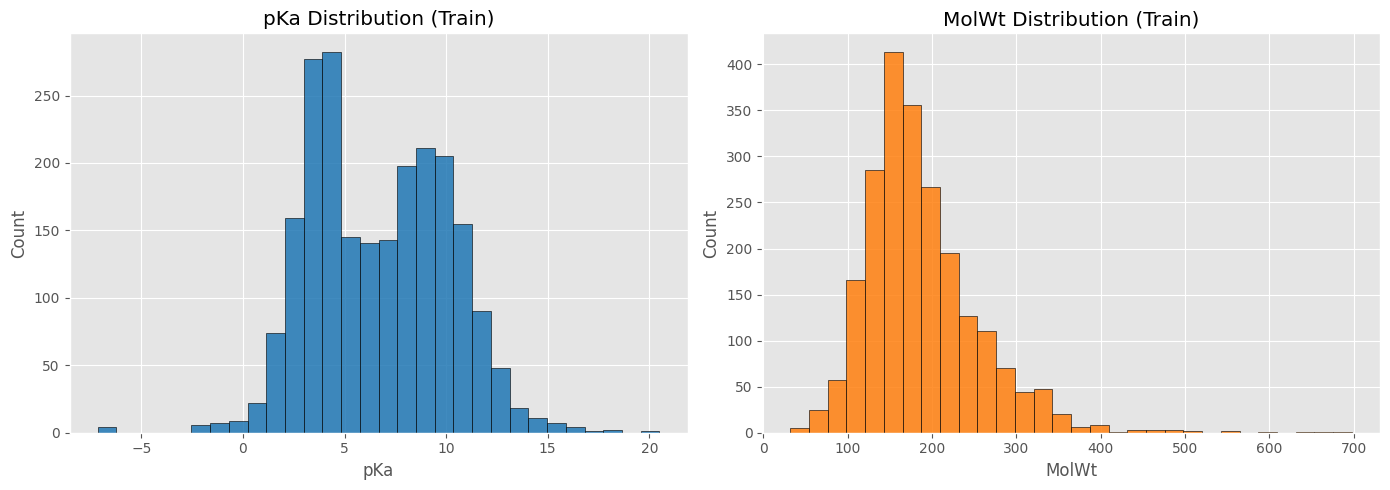

In [4]:
train_mols = [Chem.MolFromSmiles(s) for s in train_df['smiles']]
test_mols = [Chem.MolFromSmiles(s) for s in test_df['smiles']]
mol_wts = [Descriptors.MolWt(m) for m in train_mols]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(train_df['pKa'], bins=30, color='#1f77b4', edgecolor='black', alpha=0.85)
axes[0].set_title('pKa Distribution (Train)')
axes[0].set_xlabel('pKa')
axes[0].set_ylabel('Count')

axes[1].hist(mol_wts, bins=30, color='#ff7f0e', edgecolor='black', alpha=0.85)
axes[1].set_title('MolWt Distribution (Train)')
axes[1].set_xlabel('MolWt')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

In [5]:
display(train_df['pKa'].describe())
display(pd.Series(mol_wts, name='MolWt').describe())

count    2220.000000
mean        6.681135
std         3.385865
min        -7.150000
25%         3.900000
50%         6.590000
75%         9.350000
max        20.500000
Name: pKa, dtype: float64

count    2220.000000
mean      187.554135
std        67.739533
min        32.042000
25%       144.177000
50%       174.290000
75%       216.554750
max       698.021000
Name: MolWt, dtype: float64

## 3. 构建三类特征

- Morgan Fingerprint
- MACCSKeys
- RDKit 描述符

In [6]:
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
X_train_morgan = np.vstack([np.asarray(morgan_gen.GetFingerprint(m)) for m in train_mols]).astype(np.int8)
X_test_morgan = np.vstack([np.asarray(morgan_gen.GetFingerprint(m)) for m in test_mols]).astype(np.int8)

X_train_maccs = np.vstack([np.asarray(MACCSkeys.GenMACCSKeys(m)) for m in train_mols]).astype(np.int8)
X_test_maccs = np.vstack([np.asarray(MACCSkeys.GenMACCSKeys(m)) for m in test_mols]).astype(np.int8)

descriptor_names = [name for name, _ in Descriptors._descList]
X_train_desc = np.array([[func(m) for _, func in Descriptors._descList] for m in train_mols], dtype=float)
X_test_desc = np.array([[func(m) for _, func in Descriptors._descList] for m in test_mols], dtype=float)
X_train_desc = np.nan_to_num(X_train_desc, nan=0.0, posinf=0.0, neginf=0.0)
X_test_desc = np.nan_to_num(X_test_desc, nan=0.0, posinf=0.0, neginf=0.0)

y_train = train_df['pKa'].to_numpy()
y_test = test_df['pKa'].to_numpy()

print('Morgan shape:', X_train_morgan.shape)
print('MACCS shape :', X_train_maccs.shape)
print('RDKit shape :', X_train_desc.shape)

Morgan shape: (2220, 2048)
MACCS shape : (2220, 167)
RDKit shape : (2220, 217)


## 4. sklearn 多模型快速比较

先用 Morgan 指纹做一个模型筛选。

In [10]:
def calc_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'R2': r2_score(y_true, y_pred),
    }

cv = KFold(n_splits=5, shuffle=True, random_state=42)
models = {
    'LinearRegression': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Ridge': Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    'SVR_rbf': Pipeline([('scaler', StandardScaler()), ('model', SVR(C=10, gamma='scale'))]),
    'KNN': Pipeline([('scaler', StandardScaler()), ('model', KNeighborsRegressor(n_neighbors=7))]),
    'RandomForest': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=300, random_state=42),
}

model_rows = []
for name, model in models.items():
    cv_mae = -cross_val_score(model, X_train_morgan, y_train, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1).mean()
    fitted = clone(model)
    fitted.fit(X_train_morgan, y_train)
    pred = fitted.predict(X_test_morgan)
    metrics = calc_metrics(y_test, pred)
    model_rows.append({
        'model': name,
        'cv_MAE': round(cv_mae, 4),
        'test_MAE': round(metrics['MAE'], 4),
        'test_RMSE': round(metrics['RMSE'], 4),
        'test_R2': round(metrics['R2'], 4),
    })

model_zoo_df = pd.DataFrame(model_rows).sort_values(['test_MAE', 'test_RMSE']).reset_index(drop=True)
model_zoo_df

,model,cv_MAE,test_MAE,test_RMSE,test_R2
0,RandomForest,1.1996,1.1396,1.8420,0.7034
1,ExtraTrees,1.3643,1.2550,2.0805,0.6217
2,SVR_rbf,1.7081,1.5035,2.1038,0.6131
3,GradientBoosting,1.6025,1.5446,2.0667,0.6267
4,AdaBoost,2.5791,2.6435,3.0589,0.1821
5,KNN,2.8104,2.6800,3.4976,-0.0693
6,Ridge,3.2609,4.4663,6.9643,-3.2394
7,LinearRegression,4.0158,14.1251,21.7002,-40.1605


## 5. 随机森林交叉验证调参

In [11]:
param_grid = {
    'n_estimators': [300, 600],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 0.3],
}

def tune_rf(X_train, X_test, y_train, y_test):
    grid = GridSearchCV(
        RandomForestRegressor(random_state=42, n_jobs=-1),
        param_grid=param_grid,
        scoring='neg_mean_absolute_error',
        cv=cv,
        n_jobs=-1,
    )
    grid.fit(X_train, y_train)
    pred = grid.best_estimator_.predict(X_test)
    metrics = calc_metrics(y_test, pred)
    metrics['CV_MAE'] = -grid.best_score_
    return grid, pred, metrics

rf_morgan, pred_morgan, metrics_morgan = tune_rf(X_train_morgan, X_test_morgan, y_train, y_test)
rf_maccs, pred_maccs, metrics_maccs = tune_rf(X_train_maccs, X_test_maccs, y_train, y_test)
rf_desc, pred_desc, metrics_desc = tune_rf(X_train_desc, X_test_desc, y_train, y_test)

rf_compare_df = pd.DataFrame([
    {'feature_set': 'Morgan', **{k: round(v, 4) for k, v in metrics_morgan.items()}},
    {'feature_set': 'MACCS', **{k: round(v, 4) for k, v in metrics_maccs.items()}},
    {'feature_set': 'RDKit', **{k: round(v, 4) for k, v in metrics_desc.items()}},
]).sort_values('MAE').reset_index(drop=True)
rf_compare_df

,feature_set,MAE,RMSE,R2,CV_MAE
0,RDKit,0.9538,1.5338,0.7944,1.0556
1,MACCS,0.9813,1.5248,0.7968,1.0379
2,Morgan,1.0668,1.6767,0.7543,1.1715


In [12]:
print('Morgan best params:', rf_morgan.best_params_)
print('MACCS best params :', rf_maccs.best_params_)
print('RDKit best params :', rf_desc.best_params_)

Morgan best params: {'max_depth': None, 'max_features': 0.3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 600}
MACCS best params : {'max_depth': None, 'max_features': 0.3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 600}
RDKit best params : {'max_depth': 20, 'max_features': 0.3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 600}


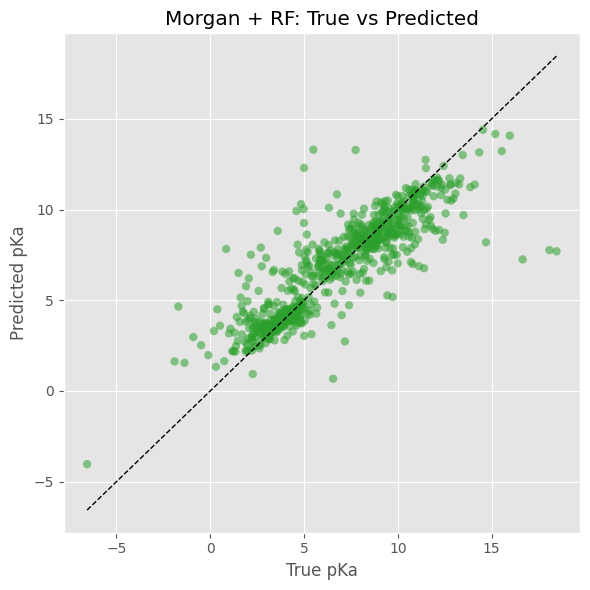

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, pred_morgan, alpha=0.55, color='#2ca02c', edgecolors='none')
min_v = min(y_test.min(), pred_morgan.min())
max_v = max(y_test.max(), pred_morgan.max())
ax.plot([min_v, max_v], [min_v, max_v], 'k--', linewidth=1)
ax.set_xlabel('True pKa')
ax.set_ylabel('Predicted pKa')
ax.set_title('Morgan + RF: True vs Predicted')
plt.tight_layout()
plt.show()

## 6. MACCSKeys 特征重要性

In [14]:
def maccs_pattern(bit_index):
    info = MACCSkeys.smartsPatts.get(int(bit_index))
    if info is None:
        return 'special/unused'
    smarts, _ = info
    return smarts if smarts != '?' else 'special key'

maccs_importance = pd.DataFrame({
    'bit': np.arange(X_train_maccs.shape[1]),
    'importance': rf_maccs.best_estimator_.feature_importances_,
}).sort_values('importance', ascending=False).head(15).reset_index(drop=True)
maccs_importance['pattern'] = maccs_importance['bit'].apply(maccs_pattern)
maccs_importance

,bit,importance,pattern
0,123,0.133253,[#8]~[#6]~[#8]
1,139,0.057014,[O;!H0]
2,49,0.055460,[!+0]
3,154,0.038135,[#6]=[#8]
4,159,0.035295,[#8]
5,130,0.019342,[!#6;!#1]~[!#6;!#1]
6,43,0.016025,[!#6;!#1;!H0]~*~[!#6;!#1;!H0]
7,70,0.015327,[!#6;!#1]~[#7]~[!#6;!#1]
8,113,0.014615,[#8]!:*:*
9,157,0.014189,[#6]-[#8]


**结果说明（MACCSKeys）**

基于随机森林的 MACCSKeys 特征重要性，前几位关键 bit（如 123、139、49、154、159）主要对应酸性官能团及其邻近结构信息。
这类位点通常反映以下化学因素：

- 羧基/类似酸性基团的存在与数量
- 芳环与共轭结构对负电荷离域的稳定作用
- 邻近杂原子（O、N、S）带来的诱导效应与极化效应

因此，MACCSKeys 的重要位与有机酸 pKa 的化学机理一致：分子越能稳定去质子化后的共轭碱，通常表现出越强酸性（pKa 越低）。

## 7. RDKit 描述符重要性

In [15]:
descriptor_meaning = {
    'MolWt': '分子量',
    'MolLogP': '疏水性/辛醇水分配倾向',
    'TPSA': '拓扑极性表面积',
    'NumHDonors': '氢键供体数',
    'NumHAcceptors': '氢键受体数',
    'MaxAbsPartialCharge': '最大绝对部分电荷',
    'MinPartialCharge': '最小部分电荷',
    'MaxPartialCharge': '最大部分电荷',
    'FpDensityMorgan1': 'Morgan 半径1指纹密度',
    'FpDensityMorgan2': 'Morgan 半径2指纹密度',
    'HallKierAlpha': '骨架与杂原子修正项',
    'BalabanJ': '拓扑连通性指数',
    'LabuteASA': '近似溶剂可及表面积',
    'HeavyAtomCount': '重原子数',
    'ExactMolWt': '精确分子量',
}

rdkit_importance = pd.DataFrame({
    'descriptor': descriptor_names,
    'importance': rf_desc.best_estimator_.feature_importances_,
}).sort_values('importance', ascending=False).head(15).reset_index(drop=True)
rdkit_importance['meaning'] = rdkit_importance['descriptor'].map(lambda x: descriptor_meaning.get(x, '与电荷分布、拓扑或分子尺寸相关'))
rdkit_importance

,descriptor,importance,meaning
0,MaxPartialCharge,0.128800,最大部分电荷
1,MinAbsPartialCharge,0.098525,与电荷分布、拓扑或分子尺寸相关
2,PEOE_VSA14,0.071992,与电荷分布、拓扑或分子尺寸相关
3,fr_COO,0.040495,与电荷分布、拓扑或分子尺寸相关
4,BCUT2D_MRLOW,0.039253,与电荷分布、拓扑或分子尺寸相关
5,fr_COO2,0.038790,与电荷分布、拓扑或分子尺寸相关
6,MinPartialCharge,0.028335,最小部分电荷
7,MinEStateIndex,0.023217,与电荷分布、拓扑或分子尺寸相关
8,MaxAbsPartialCharge,0.020477,最大绝对部分电荷
9,SMR_VSA1,0.018419,与电荷分布、拓扑或分子尺寸相关


**结果说明（RDKit 描述符）**

本次结果中，重要性靠前的 RDKit 描述符包括：`MaxPartialCharge`、`MinAbsPartialCharge`、`PEOE_VSA14`、`fr_COO`、`fr_COO2` 等。
这些特征可以归纳为三类：

- 电荷相关：部分电荷大小直接影响去质子化难易程度
- 官能团相关：`fr_COO` / `fr_COO2` 与羧酸基团数量相关，是酸性判断核心特征
- 表面积与电子分布相关：`PEOE_VSA*` 表征分子表面电子分布，影响溶剂化和共轭碱稳定性

说明模型并非只“记忆分子大小”，而是综合捕捉了官能团、电荷分布和电子环境三方面信息。

## 8. RDKit 描述符逐步特征选择

In [16]:
selector_model = RandomForestRegressor(**rf_desc.best_params_, random_state=42, n_jobs=-1)
selector = SequentialFeatureSelector(
    selector_model,
    n_features_to_select=12,
    direction='forward',
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
)
selector.fit(X_train_desc, y_train)
selected_mask = selector.get_support()
selected_desc = [descriptor_names[i] for i, keep in enumerate(selected_mask) if keep]
selected_desc

['MinAbsPartialCharge',
 'BCUT2D_MWHI',
 'PEOE_VSA14',
 'PEOE_VSA4',
 'PEOE_VSA5',
 'NumAliphaticCarbocycles',
 'fr_COO',
 'fr_COO2',
 'fr_C_O_noCOO',
 'fr_N_O',
 'fr_quatN',
 'fr_sulfide']

In [17]:
rf_desc_selected = RandomForestRegressor(**rf_desc.best_params_, random_state=42, n_jobs=-1)
rf_desc_selected.fit(X_train_desc[:, selected_mask], y_train)
pred_desc_selected = rf_desc_selected.predict(X_test_desc[:, selected_mask])
selected_metrics = calc_metrics(y_test, pred_desc_selected)
pd.DataFrame([selected_metrics])

,MAE,RMSE,R2
0,1.067504,1.754731,0.730862


**逐步选择结果讨论**

逐步前向选择保留了 12 个描述符（如 `MinAbsPartialCharge`、`PEOE_VSA14`、`fr_COO`、`fr_COO2` 等），
整体仍集中在“电荷 + 含氧官能团 + 表面积电子分布”这条主线上，化学解释合理。

但在本次数据上，逐步选择后的测试集指标约为 `MAE=1.0675`、`RMSE=1.7547`、`R2=0.7309`，
低于使用全量 RDKit 描述符的随机森林模型，说明该数据集下删减特征会损失部分有效信息。

## 9. 预测新分子的 pKa

In [18]:
new_smiles = 'CC(=O)O'  # 这里可以改成你想预测的新分子
new_mol = Chem.MolFromSmiles(new_smiles)
new_fp = np.asarray(morgan_gen.GetFingerprint(new_mol)).reshape(1, -1)
new_pred = rf_morgan.best_estimator_.predict(new_fp)[0]
print('SMILES:', new_smiles)
print('Predicted pKa:', round(float(new_pred), 4))

SMILES: CC(=O)O
Predicted pKa: 4.0585


## 10. AutoGluon 自动调参补充

In [7]:
from autogluon.tabular import TabularPredictor

In [9]:
from datetime import datetime
import importlib.util

ag_train = pd.DataFrame(X_train_desc, columns=descriptor_names)
ag_train['pKa'] = y_train
ag_test = pd.DataFrame(X_test_desc, columns=descriptor_names)
ag_test['pKa'] = y_test

def has_pkg(name: str) -> bool:
    return importlib.util.find_spec(name) is not None

# 仅启用当前环境已安装的模型，避免大量 ImportError 警告
ag_hps = {
    'RF': {},
    'XT': {},
}
if has_pkg('xgboost'):
    ag_hps['XGB'] = {}
if has_pkg('lightgbm'):
    ag_hps['GBM'] = {}
if has_pkg('catboost'):
    ag_hps['CAT'] = {}
if has_pkg('torch'):
    ag_hps['NN_TORCH'] = {}

def calc_metrics_local(y_true, y_pred):
    return {
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'RMSE': float(mean_squared_error(y_true, y_pred) ** 0.5),
        'R2': float(r2_score(y_true, y_pred)),
    }

def run_autogluon_stage(tag, time_limit, presets, num_bag_folds, num_stack_levels):
    run_path = OUTPUT_DIR / f"autogluon_{tag}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    predictor = TabularPredictor(
        label='pKa',
        problem_type='regression',
        eval_metric='r2',
        path=str(run_path)
    )
    predictor.fit(
        train_data=ag_train,
        presets=presets,
        time_limit=time_limit,
        hyperparameters=ag_hps,
        num_bag_folds=num_bag_folds,
        num_stack_levels=num_stack_levels,
        verbosity=2,
    )
    pred = predictor.predict(ag_test.drop(columns=['pKa']))
    metrics = calc_metrics_local(y_test, pred.to_numpy())
    lb = predictor.leaderboard(ag_test, silent=True)
    print(f"[{tag}] model path: {run_path}")
    display(pd.DataFrame([{**metrics, 'tag': tag, 'time_limit': time_limit}]))
    display(lb[['model', 'score_test', 'score_val', 'fit_time']].head(10))
    return predictor, metrics, lb, run_path

# Stage 1: 5分钟快速测试
ag_quick_predictor, ag_quick_metrics, ag_quick_lb, ag_quick_path = run_autogluon_stage(
    tag='quick_5min',
    time_limit=300,
    presets='medium_quality_faster_train',
    num_bag_folds=3,
    num_stack_levels=0,
)



Preset alias specified: 'medium_quality_faster_train' maps to 'medium_quality'.
Verbosity: 2 (Standard Logging)
	Failed to import torch or check CUDA availability!Please ensure you have the correct version of PyTorch installed by running `pip install -U torch`
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.15
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #74~20.04.1-Ubuntu SMP Wed Feb 22 14:52:34 UTC 2023
CPU Count:          20
Pytorch Version:    Can't import torch
CUDA Version:       Can't get cuda version from torch
Memory Avail:       9.14 GB / 15.42 GB (59.3%)
Disk Space Avail:   186.42 GB / 200.01 GB (93.2%)
Presets specified: ['medium_quality_faster_train']
Beginning AutoGluon training ... Time limit = 300s
AutoGluon will save models to "/mnt/shared/playground/AI-Chem-2026-37420232204783-黄子烨/week03/results/autogluon_quick_5min_20260327_204832"
Train Data Rows:    2220
Train Data Columns: 217
Label

[1000]	valid_set's l2: 2.32613	valid_set's r2: 0.796271
[2000]	valid_set's l2: 2.31792	valid_set's r2: 0.79699
[3000]	valid_set's l2: 2.31659	valid_set's r2: 0.797107
[4000]	valid_set's l2: 2.31646	valid_set's r2: 0.797118
[5000]	valid_set's l2: 2.31636	valid_set's r2: 0.797127
[6000]	valid_set's l2: 2.31636	valid_set's r2: 0.797127
[1000]	valid_set's l2: 2.64123	valid_set's r2: 0.769191
[2000]	valid_set's l2: 2.63705	valid_set's r2: 0.769557
[3000]	valid_set's l2: 2.63614	valid_set's r2: 0.769636
[4000]	valid_set's l2: 2.63608	valid_set's r2: 0.769641
[5000]	valid_set's l2: 2.63608	valid_set's r2: 0.769641
[1000]	valid_set's l2: 2.16129	valid_set's r2: 0.812155


	0.7931	 = Validation score   (r2)
	75.3s	 = Training   runtime
	0.1s	 = Validation runtime
Fitting model: RandomForest_BAG_L1 ... Training model for up to 224.13s of the 224.13s of remaining time.
	Fitting 1 model on all data (use_child_oof=True) | Fitting with cpus=20, gpus=0, mem=0.0/9.2 GB
	0.7599	 = Validation score   (r2)
	3.0s	 = Training   runtime
	0.13s	 = Validation runtime
Fitting model: CatBoost_BAG_L1 ... Training model for up to 220.72s of the 220.72s of remaining time.
	Fitting 3 child models (S1F1 - S1F3) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=14, gpus=0)
	Ran out of time, early stopping on iteration 9890.
	0.8039	 = Validation score   (r2)
	178.37s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: ExtraTrees_BAG_L1 ... Training model for up to 42.13s of the 42.13s of remaining time.
	Fitting 1 model on all data (use_child_oof=True) | Fitting with cpus=20, gpus=0, mem=0.0/9.0 GB
	0.7898	 = Validation score   (r2)
	0.96s	 = Tr

[quick_5min] model path: /mnt/shared/playground/AI-Chem-2026-37420232204783-黄子烨/week03/results/autogluon_quick_5min_20260327_204832


,MAE,RMSE,R2,tag,time_limit
0,0.868846,1.4212,0.823452,quick_5min,300


,model,score_test,score_val,fit_time
0,WeightedEnsemble_L2,0.823452,0.810976,254.661792
1,CatBoost_BAG_L1,0.819572,0.803875,178.371578
2,ExtraTrees_BAG_L1,0.812611,0.789806,0.957758
3,LightGBM_BAG_L1,0.810674,0.793143,75.304082
4,RandomForest_BAG_L1,0.794931,0.759906,3.003422
5,XGBoost_BAG_L1,0.768227,0.734745,37.913147


## 11. 保存结果文件

In [21]:
summary = {
    'train_rows': int(len(train_df)),
    'test_rows': int(len(test_df)),
    'feature_shapes': {
        'Morgan': list(X_train_morgan.shape),
        'MACCS': list(X_train_maccs.shape),
        'RDKit': list(X_train_desc.shape),
    },
    'rf_compare': rf_compare_df.to_dict(orient='records'),
    'maccs_top15': maccs_importance.to_dict(orient='records'),
    'rdkit_top15': rdkit_importance.to_dict(orient='records'),
    'selected_descriptors': selected_desc,
    'selected_metrics': {k: float(v) for k, v in selected_metrics.items()},
    'new_smiles': new_smiles,
    'new_smiles_predicted_pKa': float(new_pred),
}

summary_path = OUTPUT_DIR / 'results_summary.json'
pd.Series(summary).to_json(summary_path, force_ascii=False, indent=2)
model_zoo_df.to_csv(OUTPUT_DIR / 'model_zoo_morgan.csv', index=False)
rf_compare_df.to_csv(OUTPUT_DIR / 'rf_feature_compare.csv', index=False)
print('saved to:', summary_path)

saved to: /mnt/shared/playground/AI-Chem-2026-37420232204783-黄子烨/week03/results/results_summary.json


## 12. 实验结论

1. 数据集规模与特征维度
训练集 2220 个分子，测试集 740 个分子。三类特征分别为 Morgan(2048 维)、MACCSKeys(167 维)、RDKit 描述符(217 维)。

2. 随机森林在三类特征上的表现
本次结果中，RDKit 在 MAE 上最好（MAE=0.9538），MACCSKeys 在 R2 与 RMSE 上略优（R2=0.7968，RMSE=1.5248），Morgan 相对稍弱（R2=0.7543）。
这说明针对 pKa 任务，描述符类特征与结构键位特征都有效，但侧重点不同。

3. 重要特征的化学意义
MACCS 与 RDKit 的高重要性特征集中在羧基相关片段、电荷分布和电子表面性质（如 `fr_COO`、`fr_COO2`、`MaxPartialCharge`、`PEOE_VSA14`）。
这些特征与酸性本质一致：去质子化后阴离子越稳定，预测 pKa 越低。

4. 逐步特征选择结论
逐步选择结果仍保持化学可解释性，但性能下降（R2=0.7309），说明在当前样本规模下，全量描述符保留了更多有用信息。

5. AutoGluon 自动调参结果
5 分钟快速测试达到 `R2=0.8235`（MAE=0.8688，RMSE=1.4212）；
30 分钟增强训练进一步提升到 `R2=0.8307`（MAE=0.8162，RMSE=1.3916），最佳模型为集成模型（WeightedEnsemble）。
说明在允许更长训练时间时，自动集成能够进一步提升 pKa 预测精度。